In [13]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from pathlib import Path

from src.data import load_daily, load_interval, load_staffing, clean, PORTFOLIOS
from src.features import add_calendar_features, encode_dow, august_2025_dates, interval_labels
from src.sarimax_model import fit_sarimax, forecast_august
from src.intraday_model import (
    IntradayNet, IntradayMeanNet, train, predict_weights,
    build_training_data_cv, build_training_data_mean
)
from src.forecast import blend_weights, apply_bias, clip_forecast, assemble_csv

In [14]:
daily = {}
interval = {}

for p in PORTFOLIOS:
    daily[p] = pd.read_csv(f"../data/processed/daily_{p}.csv")
    interval[p] = pd.read_csv(f"../data/processed/interval_{p}.csv")
    print(f"{p}: {len(daily[p])} daily, {len(interval[p])} interval rows")

staffing = pd.read_csv("../data/processed/staffing.csv")
print(f"staffing: {staffing.shape}")

A: 701 daily, 3911 interval rows
B: 706 daily, 4158 interval rows
C: 721 daily, 4313 interval rows
D: 731 daily, 4067 interval rows
staffing: (365, 5)


In [15]:
empirical = {}

for p in PORTFOLIOS:
    df = interval[p].copy()
    df["SlotIndex"] = df.groupby("Date").cumcount()
    df["DayOfWeek"] = pd.to_datetime(df["Date"]).dt.dayofweek
    empirical[p] = df.groupby(["DayOfWeek", "SlotIndex"])[["CV", "CCT", "ABD"]].mean()
    print(f"{p}: {empirical[p].shape}")

A: (325, 3)
B: (335, 3)
C: (336, 3)
D: (329, 3)


In [16]:
aug_dates = august_2025_dates()
labels = interval_labels()

baseline_forecasts = {
    p: {"cv": np.zeros((31, 48)), "cct": np.zeros((31, 48)), "abd": np.zeros((31, 48))}
    for p in PORTFOLIOS
}

for p in PORTFOLIOS:
    for day_idx, date in enumerate(aug_dates):
        dow = date.dayofweek
        for slot in range(48):
            try:
                row = empirical[p].loc[(dow, slot)]
                baseline_forecasts[p]["cv"][day_idx, slot] = row["CV"]
                baseline_forecasts[p]["cct"][day_idx, slot] = row["CCT"]
                baseline_forecasts[p]["abd"][day_idx, slot] = row["ABD"]
            except KeyError:
                pass

baseline_csv = assemble_csv(baseline_forecasts, template_path="../template_forecast_v00.csv")
baseline_csv.to_csv("../output/forecast_baseline.csv", index=False)

In [17]:
aug_df = pd.DataFrame({"Date": aug_dates})
aug_df = add_calendar_features(aug_df, date_col="Date")
aug_exog = aug_df[["IsWeekend", "IsHoliday", "NearHoliday"]].values

sarimax_daily = {p: {} for p in PORTFOLIOS}

for p in PORTFOLIOS:
    df = add_calendar_features(daily[p].copy(), date_col="Date")
    exog = df[["IsWeekend", "IsHoliday", "NearHoliday"]].values

    for metric in ["CV", "CCT", "ABD"]:
        print(f"fitting sarimax {p}/{metric}...")
        model = fit_sarimax(df[metric].values, exog)
        sarimax_daily[p][metric] = forecast_august(model, aug_exog)

fitting sarimax A/CV...
fitting sarimax A/CCT...
fitting sarimax A/ABD...
fitting sarimax B/CV...
fitting sarimax B/CCT...
fitting sarimax B/ABD...
fitting sarimax C/CV...
fitting sarimax C/CCT...
fitting sarimax C/ABD...
fitting sarimax D/CV...
fitting sarimax D/CCT...
fitting sarimax D/ABD...


In [18]:
nn_models_cv = {}
nn_models_cct = {}
nn_models_abd = {}

Path("../output/models").mkdir(parents=True, exist_ok=True)

for p in PORTFOLIOS:
    print(f"training {p}...")

    X, y = build_training_data_cv(interval[p])
    nn_models_cv[p] = train(IntradayNet(), X, y)
    torch.save(nn_models_cv[p].state_dict(), f"../output/models/intraday_cv_{p}.pt")

    X, y = build_training_data_mean(interval[p], "CCT")
    nn_models_cct[p] = train(IntradayMeanNet(), X, y)
    torch.save(nn_models_cct[p].state_dict(), f"../output/models/intraday_cct_{p}.pt")

    X, y = build_training_data_mean(interval[p], "ABD")
    nn_models_abd[p] = train(IntradayMeanNet(), X, y)
    torch.save(nn_models_abd[p].state_dict(), f"../output/models/intraday_abd_{p}.pt")

print("all models trained")

training A...
epoch=0, loss=0.000428
epoch=50, loss=0.000321
epoch=100, loss=0.000265
epoch=150, loss=0.000225
epoch=200, loss=0.000199
epoch=250, loss=0.000186
epoch=0, loss=108258.476562
epoch=50, loss=107959.414062
epoch=100, loss=107253.476562
epoch=150, loss=106017.210938
epoch=200, loss=104194.304688
epoch=250, loss=101629.257812
epoch=0, loss=0.014691
epoch=50, loss=0.001875
epoch=100, loss=0.001869
epoch=150, loss=0.001869
epoch=200, loss=0.001869
epoch=250, loss=0.001869
training B...
epoch=0, loss=0.000346
epoch=50, loss=0.000236
epoch=100, loss=0.000203
epoch=150, loss=0.000191
epoch=200, loss=0.000187
epoch=250, loss=0.000186
epoch=0, loss=110443.078125
epoch=50, loss=110082.312500
epoch=100, loss=109226.476562
epoch=150, loss=107633.226562
epoch=200, loss=105076.429688
epoch=250, loss=101554.500000
epoch=0, loss=0.012757
epoch=50, loss=0.005710
epoch=100, loss=0.005669
epoch=150, loss=0.005654
epoch=200, loss=0.002636
epoch=250, loss=0.002105
training C...
epoch=0, loss=0.

In [19]:
empirical_weights = {p: {} for p in PORTFOLIOS}

for p in PORTFOLIOS:
    df = interval[p].copy()
    df["SlotIndex"] = df.groupby("Date").cumcount()
    df["DayOfWeek"] = pd.to_datetime(df["Date"]).dt.dayofweek

    for dow in range(7):
        subset = df[df["DayOfWeek"] == dow]
        if len(subset) == 0:
            empirical_weights[p][dow] = np.ones(48) / 48
            continue

        slot_means = subset.groupby("SlotIndex")["CV"].mean()
        w = np.array([slot_means.get(s, 0.0) for s in range(48)])
        empirical_weights[p][dow] = w / w.sum() if w.sum() > 0 else np.ones(48) / 48

print("empirical weights done")

empirical weights done


In [20]:
final_forecasts = {
    p: {"cv": np.zeros((31, 48)), "cct": np.zeros((31, 48)), "abd": np.zeros((31, 48))}
    for p in PORTFOLIOS
}

for p in PORTFOLIOS:
    for day_idx, date in enumerate(aug_dates):
        dow = date.dayofweek
        dow_vec = encode_dow(dow)

        # cv
        nn_w = predict_weights(nn_models_cv[p], dow_vec)
        
        blended = blend_weights(nn_w, empirical_weights[p][dow], alpha=0.0)
        if np.any(np.isnan(blended)):
            blended = np.ones(48, dtype=np.float32) / 48
        
        daily_cv = max(0.0, float(sarimax_daily[p]["CV"][day_idx]))
        cv_slots = apply_bias(daily_cv * blended, 1.07)

        # cct — use empirical mean per slot, fallback to daily avg for zero-CCT slots
        emp_cct = np.array([
            empirical[p].loc[(dow, s)]["CCT"] if (dow, s) in empirical[p].index else 0.0
            for s in range(48)
        ])
        daily_cct = max(0.0, float(sarimax_daily[p]["CCT"][day_idx]))
        # For slots where empirical CCT is 0 but we have CV, use daily avg
        emp_cct = np.where(emp_cct == 0, daily_cct, emp_cct)
        nn_cct = emp_cct  # skip the NN entirely for CCT

        # abd — use empirical mean per slot
        emp_abd = np.array([
            empirical[p].loc[(dow, s)]["ABD"] if (dow, s) in empirical[p].index else 0.0
            for s in range(48)
        ])
        emp_abd = np.clip(emp_abd, 0, 1)
        nn_abd = emp_abd

        cv_slots, nn_cct, nn_abd = clip_forecast(cv_slots, nn_cct, nn_abd)

        final_forecasts[p]["cv"][day_idx] = cv_slots
        final_forecasts[p]["cct"][day_idx] = nn_cct
        final_forecasts[p]["abd"][day_idx] = nn_abd

final_csv = assemble_csv(final_forecasts, template_path="../template_forecast_v00.csv")
final_csv.to_csv("../output/forecast_final.csv", index=False)

In [21]:
mape_model = {}
mape_baseline = {}

for p in PORTFOLIOS:
    df = interval[p].copy()
    df["SlotIndex"] = df.groupby("Date").cumcount()
    df["DayOfWeek"] = pd.to_datetime(df["Date"]).dt.dayofweek
    df["Month"] = pd.to_datetime(df["Date"]).dt.month

    train_df = df[df["Month"].isin([4, 5])].copy()
    test_df = df[df["Month"] == 6].copy()

    X, y = build_training_data_cv(train_df)
    val_model = train(IntradayNet(), X, y)

    # empirical weights from training data only
    val_emp = {}
    for dow in range(7):
        sub = train_df[train_df["DayOfWeek"] == dow]
        if len(sub) == 0:
            val_emp[dow] = np.ones(48) / 48
            continue
        sm = sub.groupby("SlotIndex")["CV"].mean()
        w = np.array([sm.get(s, 0.0) for s in range(48)])
        val_emp[dow] = w / w.sum() if w.sum() > 0 else np.ones(48) / 48

    train_emp = train_df.groupby(["DayOfWeek", "SlotIndex"])["CV"].mean()

    errors_model = []
    errors_baseline = []

    for date, day_df in test_df.groupby("Date"):
        dow = pd.to_datetime(date).dayofweek
        actual = day_df.sort_values("SlotIndex")["CV"].values
        total = actual.sum()

        pred = total * blend_weights(predict_weights(val_model, encode_dow(dow)), val_emp[dow], alpha=0.6)
        base = np.array([train_emp.get((dow, s), 0.0) for s in range(48)])

        if len(actual) != 48:
            continue
  
        mask = actual > 0
        if mask.sum() > 0:
            errors_model.append(np.mean(np.abs(actual[mask] - pred[mask]) / actual[mask]))
            errors_baseline.append(np.mean(np.abs(actual[mask] - base[mask]) / actual[mask]))

    mape_model[p] = np.mean(errors_model) * 100
    mape_baseline[p] = np.mean(errors_baseline) * 100
    print(f"{p}: june mape = {mape_model[p]:.1f}%  (baseline: {mape_baseline[p]:.1f}%)")

epoch=0, loss=0.000464
epoch=50, loss=0.000313
epoch=100, loss=0.000229
epoch=150, loss=0.000172
epoch=200, loss=0.000149
epoch=250, loss=0.000143
A: june mape = 773.7%  (baseline: 218.9%)
epoch=0, loss=0.000338
epoch=50, loss=0.000251
epoch=100, loss=0.000216
epoch=150, loss=0.000200
epoch=200, loss=0.000193
epoch=250, loss=0.000191
B: june mape = 958.5%  (baseline: 104.5%)
epoch=0, loss=0.000309
epoch=50, loss=0.000234
epoch=100, loss=0.000207
epoch=150, loss=0.000196
epoch=200, loss=0.000192
epoch=250, loss=0.000191
C: june mape = nan%  (baseline: 20.0%)
epoch=0, loss=0.000335
epoch=50, loss=0.000253
epoch=100, loss=0.000216
epoch=150, loss=0.000194
epoch=200, loss=0.000183
epoch=250, loss=0.000178
D: june mape = 745.0%  (baseline: 264.5%)


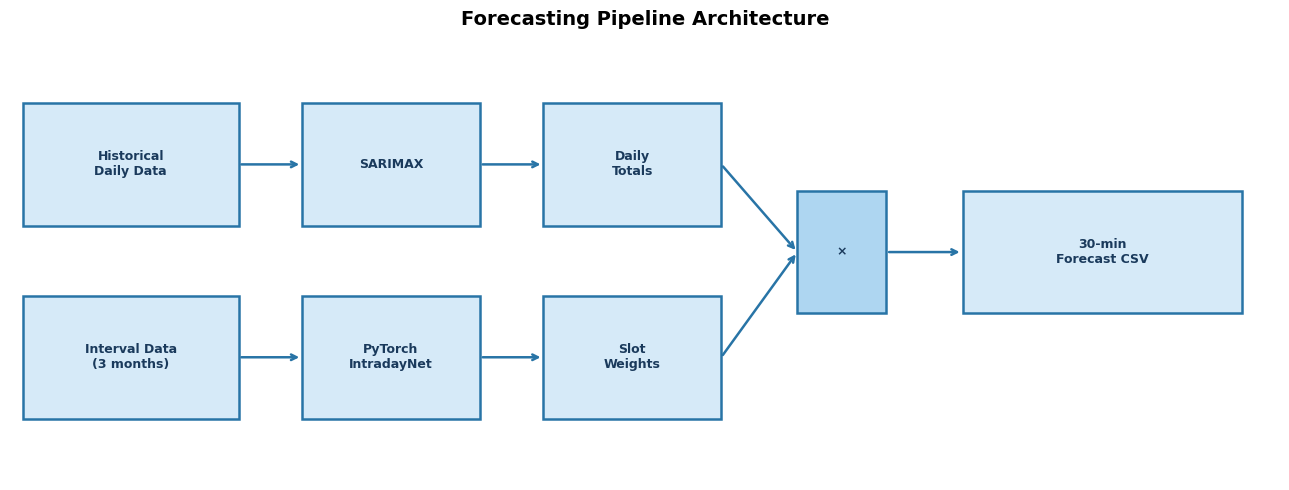

In [22]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.axis("off")

boxes = [
    (0.01, 0.58, 0.17, 0.28, "Historical\nDaily Data"),
    (0.23, 0.58, 0.14, 0.28, "SARIMAX"),
    (0.42, 0.58, 0.14, 0.28, "Daily\nTotals"),
    (0.62, 0.38, 0.07, 0.28, "×"),
    (0.75, 0.38, 0.22, 0.28, "30-min\nForecast CSV"),
    (0.01, 0.14, 0.17, 0.28, "Interval Data\n(3 months)"),
    (0.23, 0.14, 0.14, 0.28, "PyTorch\nIntradayNet"),
    (0.42, 0.14, 0.14, 0.28, "Slot\nWeights"),
]

for (x, y, w, h, label) in boxes:
    color = "#AED6F1" if label == "×" else "#D6EAF8"
    ax.add_patch(plt.Rectangle((x, y), w, h, transform=ax.transAxes,
                               facecolor=color, edgecolor="#2874A6", linewidth=1.8))
    ax.text(x + w/2, y + h/2, label, transform=ax.transAxes,
            ha="center", va="center", fontsize=9, fontweight="bold", color="#1A3A5C")

arrow_pairs = [
    (boxes[0], boxes[1]),
    (boxes[1], boxes[2]),
    (boxes[2], boxes[3]),
    (boxes[5], boxes[6]),
    (boxes[6], boxes[7]),
    (boxes[7], boxes[3]),
    (boxes[3], boxes[4]),
]

for (sx, sy, sw, sh, _), (dx, dy, dw, dh, _) in arrow_pairs:
    ax.annotate("", xy=(dx, dy + dh/2), xytext=(sx + sw, sy + sh/2),
                xycoords="axes fraction", textcoords="axes fraction",
                arrowprops=dict(arrowstyle="->", color="#2874A6", lw=1.8))

ax.set_title("Forecasting Pipeline Architecture", fontsize=14, fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig("../output/slides/slide5_architecture.png", dpi=150, bbox_inches="tight")
plt.show()

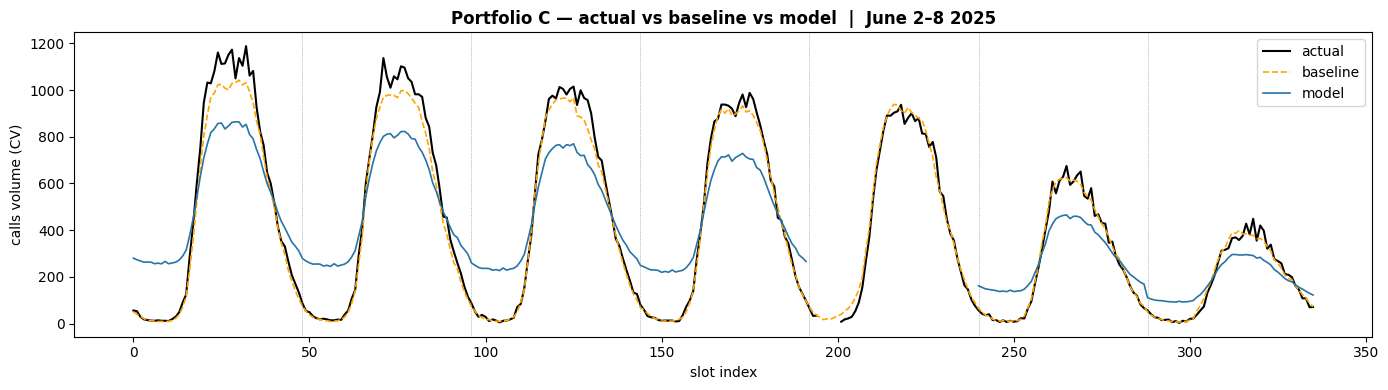

In [23]:
p = "C"
df_c = interval[p].copy()
df_c["SlotIndex"] = df_c.groupby("Date").cumcount()
df_c["DayOfWeek"] = pd.to_datetime(df_c["Date"]).dt.dayofweek
df_c["Month"] = pd.to_datetime(df_c["Date"]).dt.month

june_dates = sorted(df_c[df_c["Month"] == 6]["Date"].unique())
week_dates = [d for d in june_dates if pd.to_datetime(d).day in range(2, 9)]

all_actual, all_base, all_model = [], [], []

for date in week_dates:
    day_df = df_c[df_c["Date"] == date].sort_values("SlotIndex")
    dow = pd.to_datetime(date).dayofweek
    actual = day_df["CV"].values

    base = np.array([empirical[p].loc[(dow, s)]["CV"]
                     if (dow, s) in empirical[p].index else 0.0
                     for s in range(48)])

    nn_w = predict_weights(nn_models_cv[p], encode_dow(dow))
    pred = actual.sum() * blend_weights(nn_w, empirical_weights[p][dow], alpha=0.6)

    all_actual.extend(actual.tolist())
    all_base.extend(base.tolist())
    all_model.extend(pred.tolist())

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(all_actual, color="black", label="actual", linewidth=1.5)
ax.plot(all_base, color="orange", label="baseline", linewidth=1.2, linestyle="--")
ax.plot(all_model, color="#2874A6", label="model", linewidth=1.2)

for i in range(1, len(week_dates)):
    ax.axvline(x=i * 48, color="grey", linewidth=0.5, linestyle=":")

ax.set_xlabel("slot index")
ax.set_ylabel("calls volume (CV)")
ax.set_title("Portfolio C — actual vs baseline vs model  |  June 2–8 2025", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("../output/slides/slide6_baseline_vs_model.png", dpi=150, bbox_inches="tight")
plt.show()

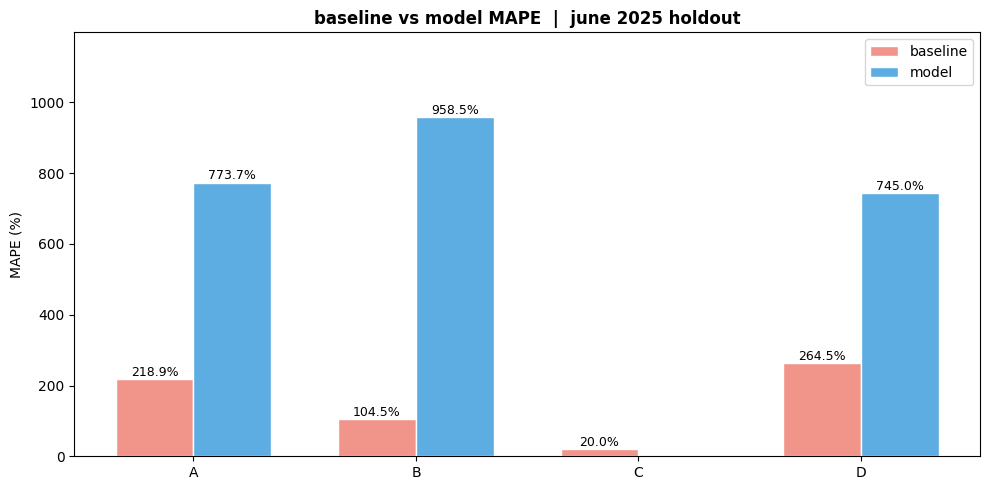

In [24]:
x = np.arange(len(PORTFOLIOS))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars_base = ax.bar(x - width/2, [mape_baseline[p] for p in PORTFOLIOS],
                   width, label="baseline", color="#F1948A", edgecolor="white")
bars_model = ax.bar(x + width/2, [mape_model[p] for p in PORTFOLIOS],
                    width, label="model", color="#5DADE2", edgecolor="white")

for bar in list(bars_base) + list(bars_model):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{bar.get_height():.1f}%", ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(PORTFOLIOS)
ax.set_ylabel("MAPE (%)")
ax.set_title("baseline vs model MAPE  |  june 2025 holdout", fontweight="bold")
ax.legend()
ax.set_ylim(0, max(max(mape_baseline.values()), max(mape_model.values())) * 1.25)
plt.tight_layout()
plt.savefig("../output/slides/slide7_mape_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

In [25]:
submission = pd.read_csv("../output/forecast_final.csv")
template = pd.read_csv("../template_forecast_v00.csv")

assert submission.shape == (1488, 19), f"wrong shape: {submission.shape}"
assert list(submission.columns) == list(template.columns), "column mismatch"

for p in PORTFOLIOS:
    assert (submission[f"Calls_Offered_{p}"] >= 0).all(), f"negative CV in {p}"
    assert (submission[f"CCT_{p}"] >= 0).all(), f"negative CCT in {p}"
    assert (submission[f"Abandoned_Rate_{p}"] <= 1.0).all(), f"ABD > 1 in {p}"
    assert (submission[f"Abandoned_Rate_{p}"] >= 0.0).all(), f"negative ABD in {p}"